# 03 - Model Training & Evaluation
---
**Objective:** Train and evaluate machine learning models

**Models:**
- Logistic Regression (baseline)
- Random Forest
- XGBoost
- LightGBM

**Metrics:**
- Precision, Recall, F1-Score
- ROC-AUC
- Confusion Matrix
- PR Curve

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data.loader import load_csv, save_file
from src.models.trainer import (
    split_data, encoding, class_weights, smote_oversampling, 
    clean_feature_names, undersampling
    )
from src.models.evaluator import evaluate_model, evaluate_threshold, plot_PR_curve

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Python version: 3.13.5
Pandas version: 2.3.1
NumPy version: 2.3.2


In [2]:
# Load data
train = load_csv('../data/processed/train_final.csv')
print()
test = load_csv('../data/processed/test_final.csv')

👉 Loading: ../data/processed/train_final.csv
DATASET INFORMATION
Shape: 1,296,675 rows × 31 columns
Memory usage: 770.12 MB

Column types:
int64      13
float64    11
object      7
Name: count, dtype: int64

Missing values: 0

👉 Loading: ../data/processed/test_final.csv
DATASET INFORMATION
Shape: 555,719 rows × 31 columns
Memory usage: 330.06 MB

Column types:
float64    12
int64      12
object      7
Name: count, dtype: int64

Missing values: 0


## A. Prepare Data for Modeling

In [3]:
# Split data
X_train, y_train = split_data(train)
X_test, y_test = split_data(test)

In [4]:
# Clean feature names
X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

In [5]:
# Encode categorical features
X_train, X_test = encoding(X_train, X_test)

Feature shape: (1296675, 30)


In [6]:
# Handle imbalance (class weight)
scale_pos_weight = class_weights(y_train)

scale_pos_weight: 171.75


In [7]:
# SMOTE oversampling
X_smote, y_smote = smote_oversampling(X_train, y_train)

After SMOTE:
is_fraud
0    1289169
1     257833
Name: count, dtype: int64


In [8]:
# Undersampling
X_under, y_under = undersampling(X_train, y_train, strategy=0.1)

After undersampling:
is_fraud
0    75060
1     7506
Name: count, dtype: int64


## B. Train Models

In [9]:
# Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=200, class_weight='balanced')
lr_model.fit(X_train, y_train)

evaluate_model(lr_model, X_test, y_test, "Logistic Regression")


🔹 Logistic Regression
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86    553574
           1       0.01      0.70      0.02      2145

    accuracy                           0.75    555719
   macro avg       0.50      0.73      0.44    555719
weighted avg       0.99      0.75      0.86    555719

ROC-AUC: 0.7900391558569146
PR-AUC: 0.07214068104072248
Confusion Matrix:
[[417872 135702]
 [   647   1498]]


In [10]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test, "Random Forest")


🔹 Random Forest
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.88      0.13      0.23      2145

    accuracy                           1.00    555719
   macro avg       0.94      0.57      0.62    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC: 0.92139768293381
PR-AUC: 0.4727794503810251
Confusion Matrix:
[[553534     40]
 [  1856    289]]


In [11]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test, "XGBoost")


🔹 XGBoost
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.71      0.29      0.42      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.65      0.71    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC: 0.9527535921418221
PR-AUC: 0.39624556544724404
Confusion Matrix:
[[553313    261]
 [  1514    631]]


In [12]:
# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train)

evaluate_model(lgb_model, X_test, y_test, "LightGBM")

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5089
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146050
[LightGBM] [Info] Start training from score -5.146050

🔹 LightGBM
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.24      0.19      0.21      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.59      0.60    555719
weighted avg       0.99      0.99      0.99    555719

ROC-AUC: 0.8716721742972976
PR-AUC: 0.1723593475784123
Confusion Matrix:
[[552275   1299]
 [  1745  

## C. Evaluation

### Feature importance

In [13]:
# Feature importance
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                Feature  Importance
21           amt_zscore    0.216482
2                   amt    0.215571
20              amt_log    0.172137
19             is_night    0.096079
15                 hour    0.056768
28  category_fraud_rate    0.039361
29      city_fraud_rate    0.031960
25        category_freq    0.031678
1              category    0.027620
27  merchant_fraud_rate    0.025048
24        merchant_freq    0.023300
26            city_freq    0.010352
22                  age    0.008839
10             city_pop    0.005000
12            unix_time    0.004137
0              merchant    0.003323
23          distance_km    0.002948
4                street    0.002894
14           merch_long    0.002890
11                  job    0.002877
5                  city    0.002789
13            merch_lat    0.002752
7                   zip    0.002571
8                   lat    0.002542
9                  long    0.002407
17                month    0.002189
6                 state    0

In [14]:
# Permutation importance
result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring='average_precision',  
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean,
    'Importance Std': result.importances_std
}).sort_values(by='Importance', ascending=False)
            
print(perm_df)

                Feature  Importance  Importance Std
2                   amt    0.391444        0.000087
15                 hour    0.257476        0.001234
22                  age    0.247080        0.004034
1              category    0.217416        0.002977
25        category_freq    0.203224        0.003225
28  category_fraud_rate    0.162523        0.004033
3                gender    0.054408        0.003010
10             city_pop    0.041957        0.002492
24        merchant_freq    0.025151        0.001420
27  merchant_fraud_rate    0.016327        0.000742
17                month    0.001913        0.000468
0              merchant    0.001773        0.000647
23          distance_km    0.000204        0.000500
12            unix_time    0.000000        0.000000
18           is_weekend    0.000000        0.000000
20              amt_log    0.000000        0.000000
21           amt_zscore    0.000000        0.000000
4                street   -0.000451        0.000739
16          

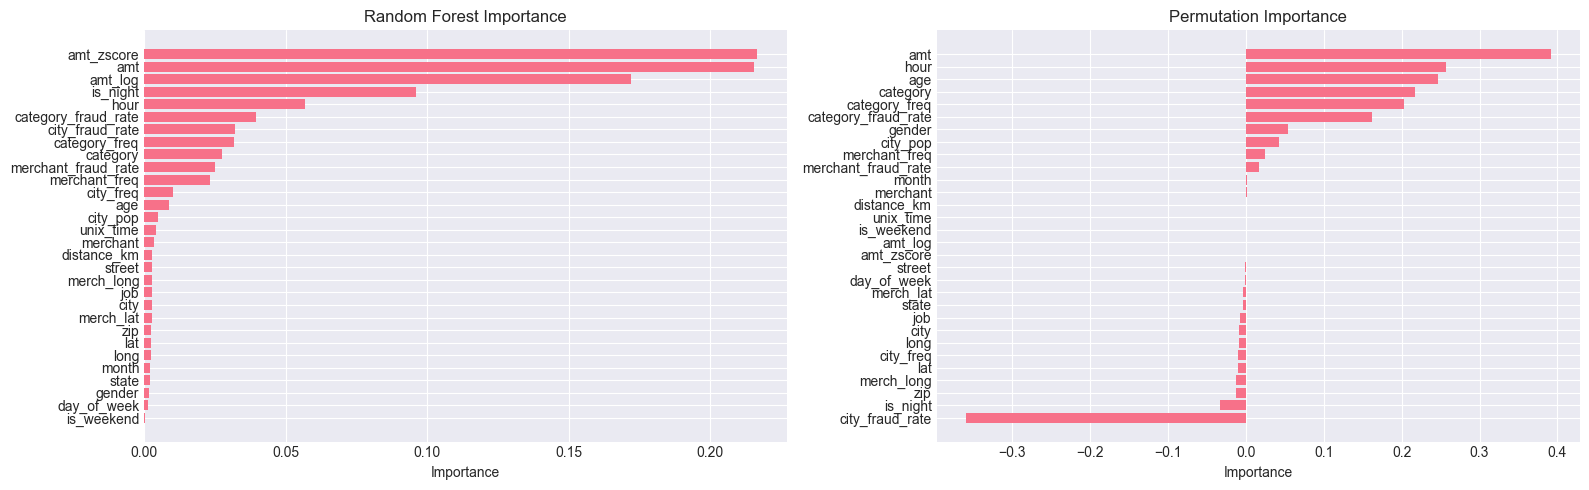

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: RF feature importance
axes[0].barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Importance")
axes[0].set_xlabel("Importance")

# Plot 2: Permutation importance
axes[1].barh(perm_df['Feature'], perm_df['Importance'])
axes[1].invert_yaxis()
axes[1].set_title("Permutation Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

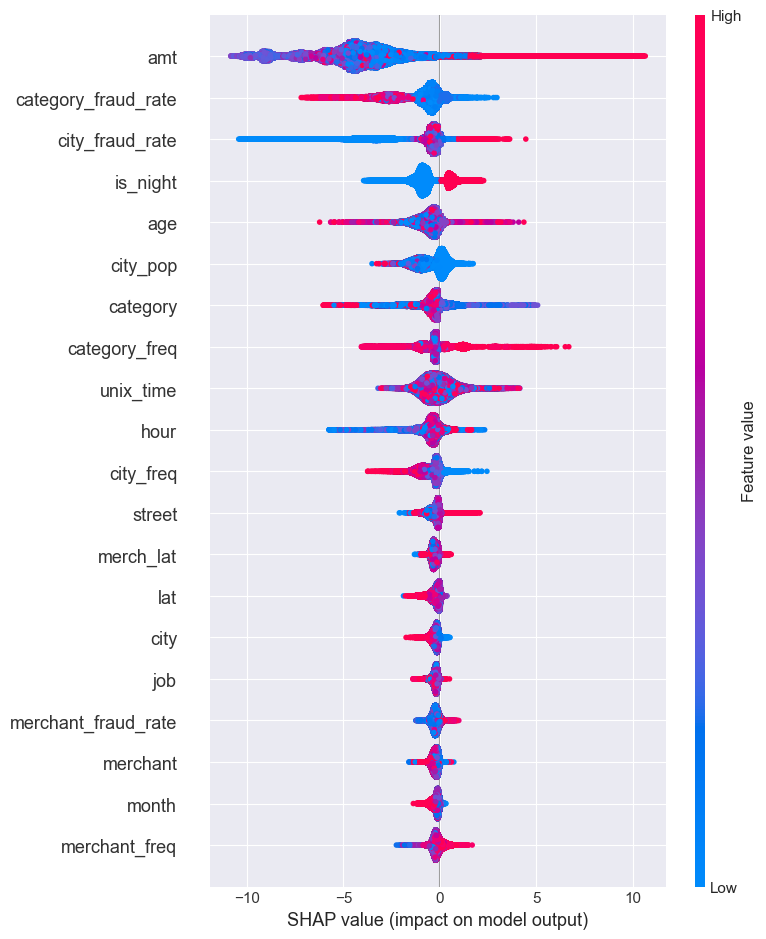

In [ ]:
# SHAP
explainer = shap.TreeExplainer(xgb_model)  
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

### Evaluate thresholds

In [16]:
# Evaluate thresholds
evaluate_threshold(xgb_model, X_test, y_test, 0.5, "XGBoost")
evaluate_threshold(xgb_model, X_test, y_test, 0.3, "XGBoost")
evaluate_threshold(xgb_model, X_test, y_test, 0.2, "XGBoost")


🔹 XGBoost (Threshold = 0.5)
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.71      0.29      0.42      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.65      0.71    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC: 0.9527535921418221
PR-AUC: 0.39624556544724404
Confusion Matrix:
[[553313    261]
 [  1514    631]]

🔹 XGBoost (Threshold = 0.3)
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.63      0.32      0.42      2145

    accuracy                           1.00    555719
   macro avg       0.81      0.66      0.71    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC: 0.9527535921418221
PR-AUC: 0.39624556544724404
Confusion Matrix:
[[553174    400]
 [  14

### PR Curve

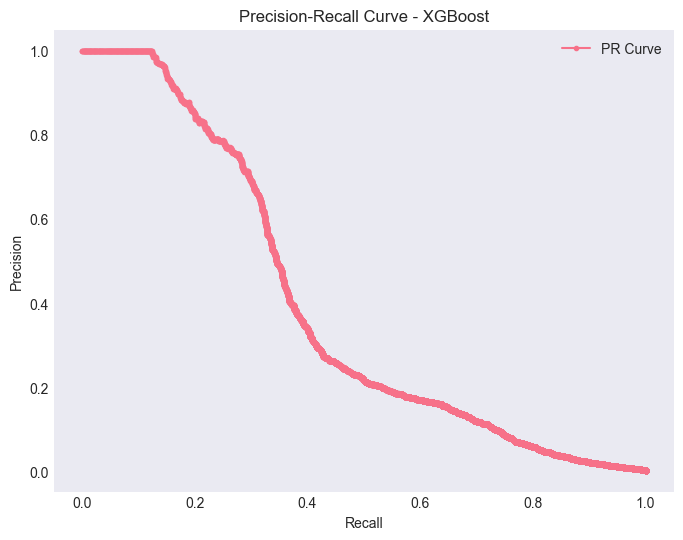

In [17]:
# Plot PR Curve
plot_PR_curve(xgb_model, X_test, y_test, name="XGBoost")